# 05 - Explainable AI (XAI) con SHAP

Come step finale del processo di Knowledge Discovery in Databases (KDD), è essenziale "aprire la black-box" dei modelli di Machine Learning. In ambito finanziario, gli investitori richiedono trasparenza sui driver che generano i segnali di trading.

In questo notebook utilizziamo **SHAP (SHapley Additive exPlanations)** basato sulla teoria dei giochi. Applicheremo il *TreeExplainer* al modello **Random Forest** addestrato sul dataset *Macro-Bond*, per analizzare l'interpretabilità su due livelli:
1. **Analisi Globale:** Quali sono le feature più importanti per il modello in generale.
2. **Analisi Locale:** Come le singole feature hanno contribuito a una specifica predizione (waterfall plot).

In [3]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
# Evitiamo warning fastidiosi
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Carichiamo il Dataset e ricreiamo il target

df= pd.read_csv('/content/drive/MyDrive/Bond_screener/data/df_bond_macro_lagged.csv', index_col=0).reset_index()

if 'index' in df.columns:
    df = df.rename(columns={'index': 'isincode'})

df['referencedate'] = pd.to_datetime(df['referencedate'])

FORECAST_HORIZON = 30
df = df.sort_values(by=['isincode', 'referencedate']).reset_index(drop=True)
df['ytm_target'] = df.groupby('isincode')['yield_to_maturity'].shift(-FORECAST_HORIZON)
df = df.dropna(subset=['ytm_target']).copy()
df['target'] = (df['ytm_target'] < df['yield_to_maturity']).astype(int)



In [5]:
# Selezione del test
# Vogliamo spiegare le previsioni fatte sull'ultimo periodo di test (Out-of-Sample)

unique_dates = np.sort(df['referencedate'].unique())
n_splits = 5
test_size_days = len(unique_dates) // (n_splits + 1)

# Calcoliamo gli indici solo per il Fold 5 (indice 4 nel ciclo for)
fold = 4
test_start_idx = len(unique_dates) - test_size_days * (n_splits - fold)
test_end_idx = test_start_idx + test_size_days
test_dates = unique_dates[test_start_idx:test_end_idx]

df_test = df[df['referencedate'].isin(test_dates)].copy()

In [6]:
# Isoliamo le features e il target
cols_to_exclude = ['marketcode', 'referencedate', 'pricetype', 'ytm_target', 'target', 'redemptiondate', 'description', 'isincode']
feature_cols = [col for col in df.columns if col not in cols_to_exclude]

X_test_raw = df_test[feature_cols]

print(f"Test Set isolato: {X_test_raw.shape[0]} righe, {X_test_raw.shape[1]} features.")

# Carichiamo la Pipeline salvata dal Notebook 3B
print("Caricamento modello Random Forest...")
pipeline = joblib.load('/content/drive/MyDrive/Bond_screener/data/best_rf_bonds_macro_model.pkl')

# Spacchettiamo la pipeline

scaler = pipeline.named_steps['scaler']
rf_model = pipeline.named_steps['rf']

# Scaliamo i dati di test
X_test_scaled_array = scaler.transform(X_test_raw)

# Ricreiamo un DataFrame Pandas con i dati scalati per non perdere i nomi delle features nei grafici SHAP!
X_test_shap = pd.DataFrame(X_test_scaled_array, columns=feature_cols, index=df_test.index)

Test Set isolato: 53431 righe, 57 features.
Caricamento modello Random Forest...


## Inizializzazione TreeSHAP

In [7]:
# Inizializziamo il treeExplainer
explainer = shap.TreeExplainer(rf_model)

# Calcoliamo i valori SHAP per il test set scalato
shap_values = explainer.shap_values(X_test_shap)

# Essendo una classificazione binaria, SHap restituisce i valori per entrambe le classi
# ma a noi interessa solo la classe 1 ovvero "Compra"

if isinstance(shap_values, list):
    shap_values_class_1 = shap_values[1] # versioni precedenti di shap
elif len(shap_values.shape) == 3:
    shap_values_class_1 = shap_values[:, :, 1] # versioni più recenti di shap
else:
    shap_values_class_1 = shap_values # fallback, se non è una lista o un array 3D

## Analisi globale

L'analisi globale ci permette di verificare se il modello ha appreso relazioni finanziariamente sensate, evitando l'overfitting su rumore statistico.

Il **SHAP Summary Plot** mostra l'impatto direzionale delle feature:
* **Asse Y:** Le feature ordinate per importanza globale decrescente.
* **Asse X (SHAP Value):** L'impatto della feature sul logit del modello. Valori positivi spingono verso la classe 1 ("Compra"), valori negativi verso la classe 0 ("Attendi").
* **Colore:** Indica il valore assunto dalla feature (Rosso = Valore alto, Blu = Valore basso).

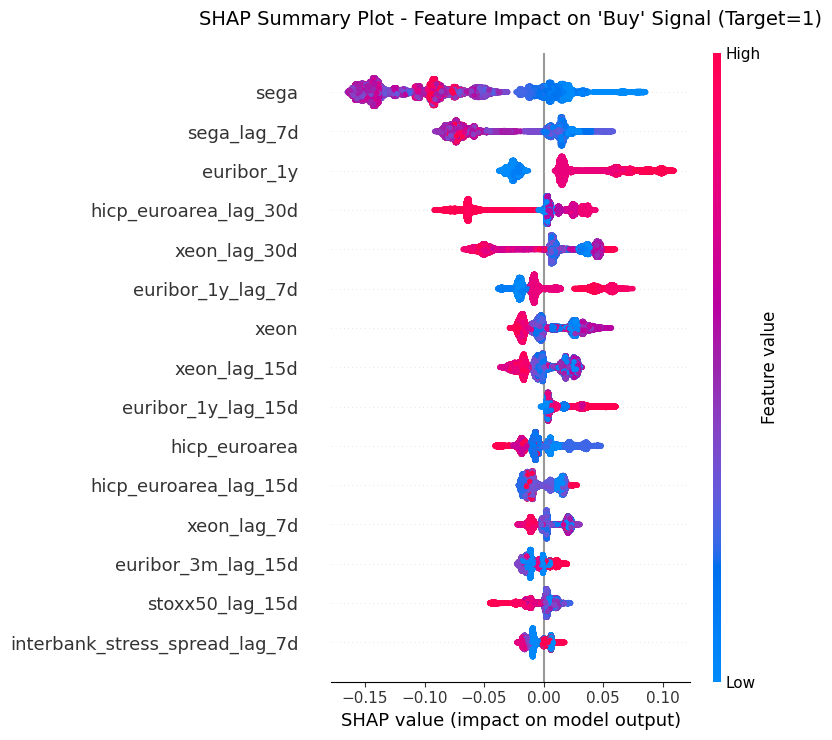

In [8]:
# Il Summary Plot mostra l'impatto di ogni feature sulla decisione del modello.
plt.figure(figsize=(10, 8))

# max_display=15 limita il grafico alle 15 variabili più influenti per renderlo leggibile
shap.summary_plot(shap_values_class_1, X_test_shap, max_display=15, show=False)

plt.title("SHAP Summary Plot - Feature Impact on 'Buy' Signal (Target=1)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


**Osservazioni dal Summary Plot:**
Dal grafico si evince che il modello attribuisce forte importanza alla macro-struttura (es. *Euribor_1Y*) e agli indicatori di mercato (es. *SEGA*, *XEON*). Ad esempio, si nota che valori bassi dell'Euribor a 1 anno (colore blu) tendono ad aumentare la probabilità del segnale "Compra" (SHAP value > 0), in linea con la teoria economica: tassi previsti al ribasso indicano un futuro apprezzamento dei bond.

## Analisi locale

Mentre l'analisi globale ci mostra i macro-trend del modello, l'analisi locale serve a validare un singolo segnale operativo. Immaginiamo che il sistema suggerisca un ingresso su uno specifico ISIN: l'investitore vuole sapere *perché proprio oggi e perché proprio su questo bond*.

Utilizziamo un **Waterfall Plot** per decomporre l'output del modello per la previsione con la più alta probabilità di "Compra". Questo grafico parte dal `base_value` (il valore atteso medio del modello) e somma/sottrae il contributo di ogni singola feature fino ad arrivare alla probabilità finale.

Analizziamo l'isin IT0005083057 in data 2026-01-12 
Probabilità prevista di 'Buy' 98.92%


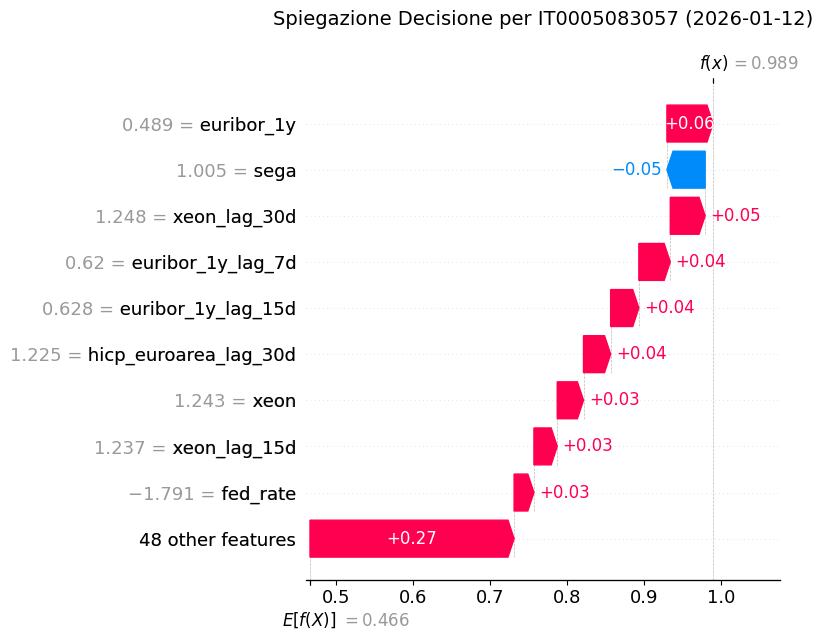

In [9]:
# calcoliamo tutte le probabilità sul test set
probs = rf_model.predict_proba(X_test_scaled_array)[:,1]

# Troviamo la riga in che ha maggiore probabilità
best_idx = np.argmax(probs)
best_isincode = df_test.iloc[best_idx]['isincode']
best_date = df_test.iloc[best_idx]['referencedate'].strftime('%Y-%m-%d')
best_prob = probs[best_idx]

print(f"Analizziamo l'isin {best_isincode} in data {best_date} ")
print(f"Probabilità prevista di 'Buy' {best_prob:.2%}")

# Estraiamo la probabilità media di base del modello
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = explainer.expected_value[1]
else:
    base_value = explainer.expected_value

# Creiamo un oggetto "Explanation" richiesto dalle nuove versioni di SHAP per il Waterfall
shap_exp = shap.Explanation(values=shap_values_class_1[best_idx],
                            base_values=base_value,
                            data=X_test_shap.iloc[best_idx].values,
                            feature_names=feature_cols)

plt.figure(figsize=(10, 6))

# max_display=10 mostra i 10 fattori più impattanti, raggruppando gli altri in "Other"
shap.plots.waterfall(shap_exp, max_display=10, show=False)

plt.title(f"Spiegazione Decisione per {best_isincode} ({best_date})", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

**Osservazioni dal Waterfall Plot:**
L'analisi del singolo bond (IT0005083057) mostra chiaramente l'interazione tra i dati. Il forte segnale "Compra" (quasi 99%) non è derivato da un singolo fattore, ma da un "effetto accumulo": l'Euribor a 1 anno basso e i rendimenti dell'ETF SEGA spingono verso l'alto la predizione. Questo tipo di scomposizione è fondamentale per garantire il trust operativo nel sistema.